<a href="https://colab.research.google.com/github/abxda/INFOTEC-Aprendizaje-No-Supervisado/blob/main/Semana_06_detecci%C3%B3n_anomalias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  DETECCION DE ANOMALIAS EN MNIST
  Actividad de clase


  Objetivo:
  Encontrar las imagenes de digitos escritos a mano (MNIST) que sean las mas
  "raras" o atipicas, usando 4 metodos distintos de deteccion de anomalias:

      1. Local Outlier Factor (LOF)
      2. DBSCAN
      3. One-Class SVM
      4. Isolation Forest

  Concepto clave:
  Una ANOMALIA (outlier) es un dato que se desvía drasticamente del
  comportamiento esperado. Imagina un salon de clase donde todos escriben
  el numero "3" de forma similar... excepto una persona que lo escribe
  de forma tan rara que parece un "8". Esa imagen seria una anomalia.

  Aplicaciones reales:
  - Fraudes bancarios: transacciones que no encajan con el patron de gasto
  - Ciberseguridad: comportamientos inusuales en una red
  - Medicina: resultados de examenes fuera de lo normal
  - Limpieza de datos: eliminar errores antes de entrenar modelos


In [ ]:
# =============================================================================
# PASO 0: Importar librerias
# =============================================================================
#
# Cada libreria tiene un rol especifico:
#   - numpy:       manejo eficiente de arreglos numericos
#   - matplotlib:  creacion de graficas
#   - sklearn:     algoritmos de machine learning (los 4 detectores)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

In [ ]:

# =============================================================================
# PASO 1: Cargar y preparar los datos de MNIST
# =============================================================================
#
# MNIST contiene 70,000 imagenes de digitos (0-9) escritos a mano.
# Cada imagen es de 28x28 pixeles = 784 valores por imagen.
#
#   Ejemplo visual de como se "aplana" una imagen:
#
#       Imagen 28x28          Vector de 784 valores
#       +---------+
#       | .##...  |  ------>  [0, 0, 0.5, 0.9, 0, 0, ..., 0.3, 0.8]
#       | #..#.   |           (un solo renglon con 784 numeros)
#       | .###.   |
#       +---------+
#
# Usamos solo los primeros 10,000 ejemplos para que el calculo sea rapido.
# Dividimos entre 255 para normalizar los pixeles al rango [0, 1].

print("Cargando MNIST (esto puede tardar la primera vez)...")
mnist = fetch_openml('mnist_784', as_frame=False)

X = mnist.data[0:10000] / 255       # Pixeles normalizados: 0=negro, 1=blanco
y = mnist.target.astype(np.uint8)[0:10000]  # Etiquetas: 0, 1, 2, ..., 9

print(f"Forma de X: {X.shape}  ->  10,000 imagenes de 784 pixeles cada una")
print(f"Forma de y: {y.shape}  ->  10,000 etiquetas (el digito real)")



Cargando MNIST (esto puede tardar la primera vez)...
Forma de X: (10000, 784)  ->  10,000 imagenes de 784 pixeles cada una
Forma de y: (10000,)  ->  10,000 etiquetas (el digito real)


In [ ]:
# =============================================================================
# FUNCIONES AUXILIARES PARA VISUALIZACION
# =============================================================================
#
# Creamos funciones reutilizables para no repetir codigo en cada metodo.
# Asi el script queda limpio y cada seccion se enfoca en lo importante.

def mostrar_16_anomalias(X, indices, titulo):
    """
    Muestra las primeras 16 anomalias en una cuadricula de 4x4.

    Parametros:
        X        : matriz de datos (cada fila es una imagen aplanada de 784 px)
        indices  : indices de las imagenes anomalas
        titulo   : titulo descriptivo para la grafica

    Ejemplo visual del resultado:
        +----+----+----+----+
        | 3? | 8? | 1? | 7? |   <-- cada celda muestra una imagen
        +----+----+----+----+       de 28x28 pixeles que el algoritmo
        | 5? | 0? | 9? | 2? |       considero "rara"
        +----+----+----+----+
        | ...                |
        +----+----+----+----+
    """
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle(titulo, fontsize=14, fontweight='bold')

    primeros_16 = indices[:16]

    for i, ax in enumerate(axes.flat):
        imagen = X[primeros_16[i]].reshape(28, 28)   # De vector a matriz 28x28
        ax.imshow(imagen, cmap='gray_r')              # gray_r: fondo blanco
        ax.set_title(f"idx={primeros_16[i]}", fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f"fig_{titulo.lower().replace(' ', '_').replace('-','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()


def contar_anomalias_por_digito(y, mascara_anomalas):
    """
    Cuenta cuantas anomalias hay por cada digito (0-9) y lo muestra
    como tabla y como grafica de barras.

    Parametros:
        y                : etiquetas reales de los digitos
        mascara_anomalas : arreglo booleano (True = anomalia)

    Ejemplo de salida:
        Digito 0:  12 anomalias
        Digito 1:   3 anomalias
        ...
        Digito 9:   8 anomalias
        Total:     87 anomalias de 10,000 imagenes
    """
    print(f"\n  {'Digito':<10} {'Anomalias':>10}")
    print(f"  {'-'*10} {'-'*10}")

    conteos = []
    for digito in range(10):
        # Contar imagenes que son de este digito Y fueron marcadas como anomalas
        n = np.sum(mascara_anomalas & (y == digito))
        conteos.append(n)
        print(f"  {digito:<10} {n:>10}")

    total = np.sum(mascara_anomalas)
    print(f"  {'TOTAL':<10} {total:>10}  de {len(y)} imagenes")

    return conteos


def graficar_conteo_por_digito(conteos, titulo):
    """
    Grafica de barras: cuantas anomalias detecto el metodo por cada digito.
    Esto nos permite ver si el algoritmo "castiga" mas a ciertos numeros.
    """
    fig, ax = plt.subplots(figsize=(8, 4))
    colores = plt.cm.tab10(np.arange(10))
    barras = ax.bar(range(10), conteos, color=colores, edgecolor='black')
    ax.set_xlabel('Digito', fontsize=12)
    ax.set_ylabel('Cantidad de anomalias', fontsize=12)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xticks(range(10))

    # Agregar el numero exacto encima de cada barra
    for barra, conteo in zip(barras, conteos):
        ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 0.3,
                str(conteo), ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig(f"fig_barras_{titulo.lower().replace(' ', '_').replace('-','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()



  MUESTRA DE DIGITOS NORMALES (para referencia)


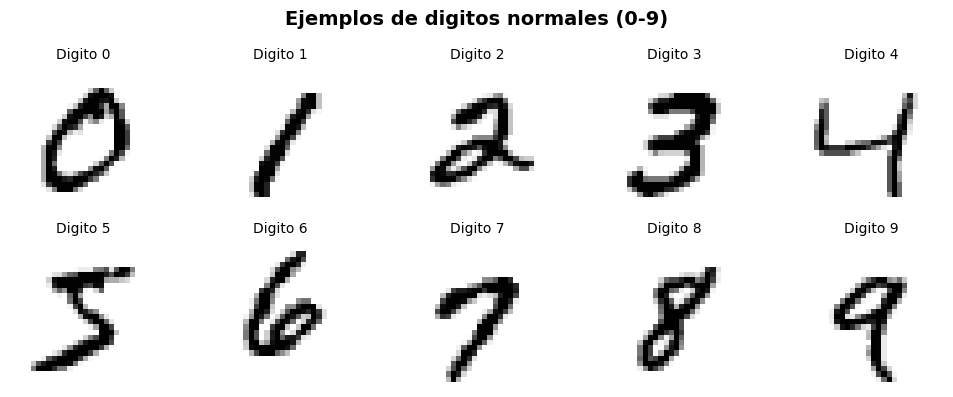

In [ ]:
# =============================================================================
# PASO 2: Visualizar algunos digitos normales (para tener referencia)
# =============================================================================
#
# Antes de buscar anomalias, veamos como lucen digitos "tipicos".
# Asi podremos comparar despues con los que los algoritmos marquen como raros.

print("\n" + "="*70)
print("  MUESTRA DE DIGITOS NORMALES (para referencia)")
print("="*70)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("Ejemplos de digitos normales (0-9)", fontsize=14, fontweight='bold')

for digito in range(10):
    ax = axes[digito // 5, digito % 5]
    # Tomar el primer ejemplo de cada digito
    idx = np.where(y == digito)[0][0]
    ax.imshow(X[idx].reshape(28, 28), cmap='gray_r')
    ax.set_title(f"Digito {digito}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig("fig_digitos_normales.png", dpi=150, bbox_inches='tight')
plt.show()


  METODO 1: LOCAL OUTLIER FACTOR (n_neighbors=4)

  Anomalias detectadas por digito:

  Digito      Anomalias
  ---------- ----------
  0                   0
  1                  26
  2                  30
  3                   7
  4                  18
  5                   5
  6                   2
  7                  11
  8                  17
  9                   3
  TOTAL             119  de 10000 imagenes


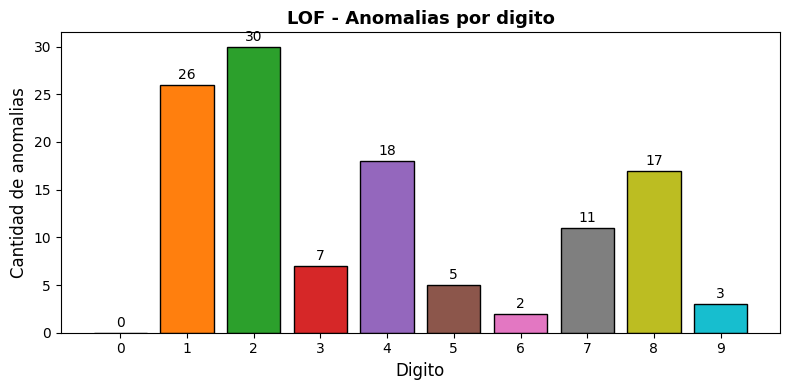


  Primeras 16 anomalias (indices): [ 53  61  67  70 132 180 212 240 318 444 472 558 588 627 644 674]


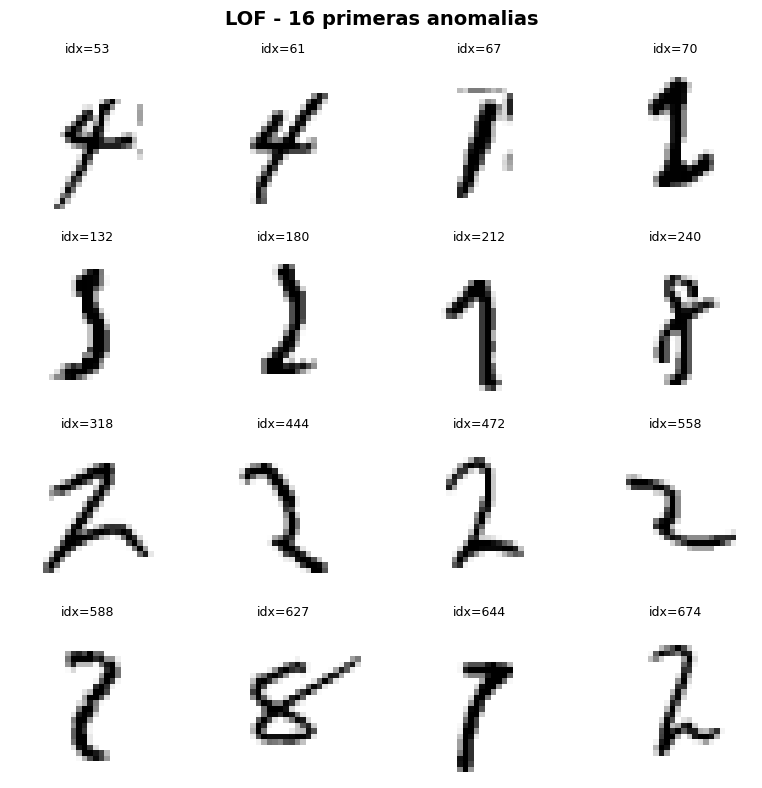

In [ ]:

# =============================================================================
#  METODO 1: LOCAL OUTLIER FACTOR (LOF)
# =============================================================================
#
#  Como funciona (analogia):
#  Imagina que vives en una ciudad. LOF mide que tan "aislado" estas
#  comparando la densidad de poblacion de tu vecindario con la de tus vecinos.
#
#     Zona densa (normal):          Zona aislada (anomalia):
#     . . . . . .                   .
#     . . x . . .   <-- x tiene     .         x   <-- x esta lejos de
#     . . . . . .       muchos          .             todos sus vecinos
#     . . . . . .       vecinos              .
#                       cerca
#
#  Si LOF ~ 1:  densidad similar a tus vecinos (normal)
#  Si LOF > 1:  mucho menos denso que tus vecinos (posible anomalia)
#
#  Parametro clave:
#  n_neighbors = 4  ->  Compara cada imagen con sus 4 vecinos mas cercanos.
#                       Un valor bajo lo hace mas sensible a anomalias locales.
#
# =============================================================================

print("\n" + "="*70)
print("  METODO 1: LOCAL OUTLIER FACTOR (n_neighbors=4)")
print("="*70)

# fit_predict devuelve:  1 = normal,  -1 = anomalia
lof = LocalOutlierFactor(n_neighbors=4)
predicciones_lof = lof.fit_predict(X)

# Crear mascara booleana: True donde el modelo detecto anomalia
es_anomalia_lof = (predicciones_lof == -1)

# --- Punto 1: Contar anomalias por digito ---
print("\n  Anomalias detectadas por digito:")
conteos_lof = contar_anomalias_por_digito(y, es_anomalia_lof)
graficar_conteo_por_digito(conteos_lof, "LOF - Anomalias por digito")

# --- Punto 2: Indices de las primeras 16 anomalias ---
indices_lof = np.where(es_anomalia_lof)[0]
print(f"\n  Primeras 16 anomalias (indices): {indices_lof[:16]}")

# --- Punto 3: Visualizar las primeras 16 anomalias ---
mostrar_16_anomalias(X, indices_lof, "LOF - 16 primeras anomalias")


  METODO 2: DBSCAN (eps=6.8, min_samples=2)

  Anomalias detectadas por digito:

  Digito      Anomalias
  ---------- ----------
  0                  21
  1                   2
  2                  63
  3                  51
  4                  16
  5                  38
  6                  21
  7                  12
  8                  87
  9                  21
  TOTAL             332  de 10000 imagenes


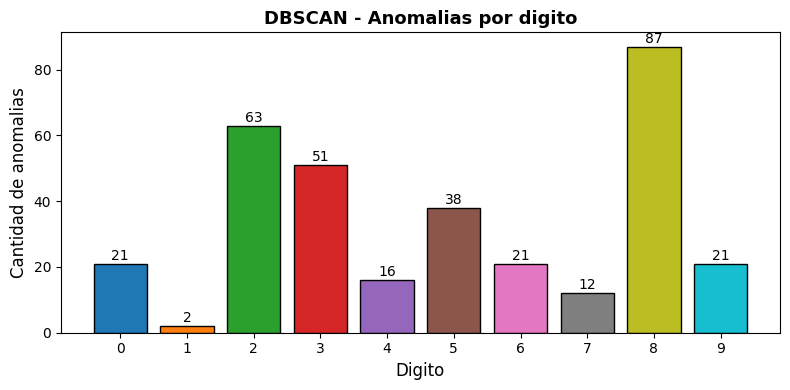


  Primeras 16 anomalias (indices): [ 28  68 111 120 306 386 391 504 517 528 544 622 626 627 670 704]


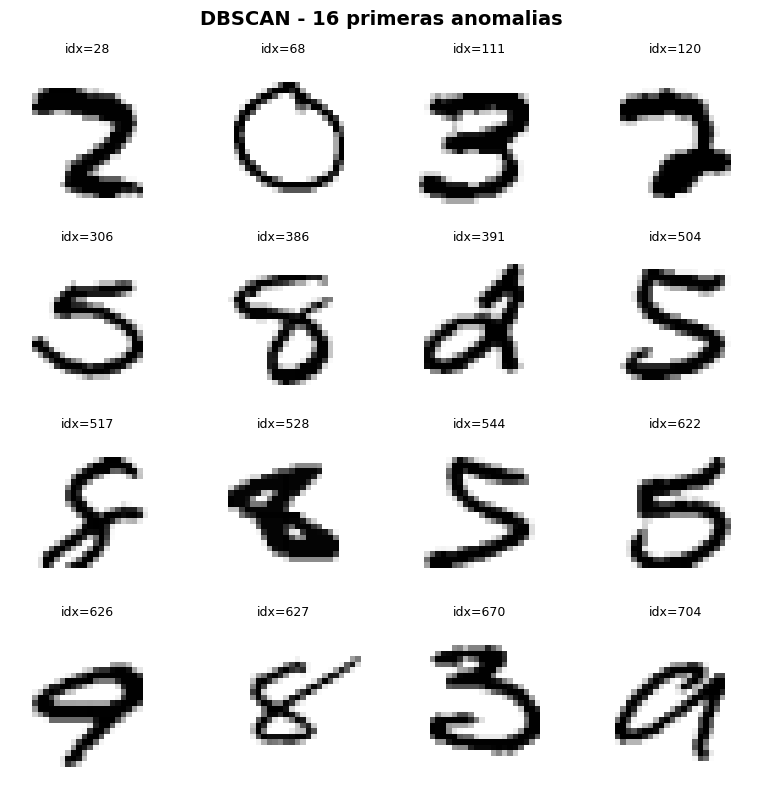

In [ ]:

# =============================================================================
#  METODO 2: DBSCAN (Aislamiento por Densidad)
# =============================================================================
#
#  Como funciona (analogia):
#  DBSCAN es como un explorador que recorre un bosque buscando "grupos"
#  de arboles. Si un arbol esta demasiado lejos de cualquier grupo,
#  lo marca como "solitario" (anomalia, etiqueta = -1).
#
#     Grupo denso (cluster):        Punto aislado (anomalia):
#       ****                                   *
#       * ** *   <-- eps define            (lejos de todo)
#       ****       el radio de
#                  busqueda
#
#  Parametros clave:
#  eps = 6.8         ->  Radio maximo para considerar dos puntos como vecinos.
#                        En 784 dimensiones, las distancias son grandes,
#                        por eso eps=6.8 (no es un valor "pequeno").
#  min_samples = 2   ->  Minimo de vecinos para formar un cluster.
#                        Con 2, basta que un punto tenga 1 companero cercano
#                        para NO ser considerado anomalia.
#
# =============================================================================

print("\n" + "="*70)
print("  METODO 2: DBSCAN (eps=6.8, min_samples=2)")
print("="*70)

dbscan = DBSCAN(eps=6.8, min_samples=2)
etiquetas_dbscan = dbscan.fit_predict(X)

# En DBSCAN, la etiqueta -1 significa "ruido" (anomalia)
es_anomalia_dbscan = (etiquetas_dbscan == -1)

# --- Punto 1: Contar anomalias por digito ---
print("\n  Anomalias detectadas por digito:")
conteos_dbscan = contar_anomalias_por_digito(y, es_anomalia_dbscan)
graficar_conteo_por_digito(conteos_dbscan, "DBSCAN - Anomalias por digito")

# --- Punto 2: Indices de las primeras 16 anomalias ---
indices_dbscan = np.where(es_anomalia_dbscan)[0]
print(f"\n  Primeras 16 anomalias (indices): {indices_dbscan[:16]}")

# --- Punto 3: Visualizar las primeras 16 anomalias ---
mostrar_16_anomalias(X, indices_dbscan, "DBSCAN - 16 primeras anomalias")




  METODO 3: ONE-CLASS SVM (kernel=rbf, nu=0.1)
  (Este metodo tarda mas, espera un momento...)

  Top 16 imagenes mas raras (indices): [1448 5972 2019 9699 8586 1466 8453 2292 3607 4841  875 2073 3106 4801
 4875 4114]
  Sus scores (distancia al hiperplano):
    # 1  idx= 1448  score=-47.5413  (digito real: 4)
    # 2  idx= 5972  score=-45.5180  (digito real: 8)
    # 3  idx= 2019  score=-44.2983  (digito real: 2)
    # 4  idx= 9699  score=-43.3497  (digito real: 0)
    # 5  idx= 8586  score=-38.8968  (digito real: 9)
    # 6  idx= 1466  score=-37.3408  (digito real: 6)
    # 7  idx= 8453  score=-37.3390  (digito real: 2)
    # 8  idx= 2292  score=-35.6065  (digito real: 7)
    # 9  idx= 3607  score=-34.0961  (digito real: 2)
    #10  idx= 4841  score=-33.0809  (digito real: 6)
    #11  idx=  875  score=-32.8453  (digito real: 3)
    #12  idx= 2073  score=-30.9482  (digito real: 2)
    #13  idx= 3106  score=-30.5215  (digito real: 0)
    #14  idx= 4801  score=-30.4253  (digito real: 5)

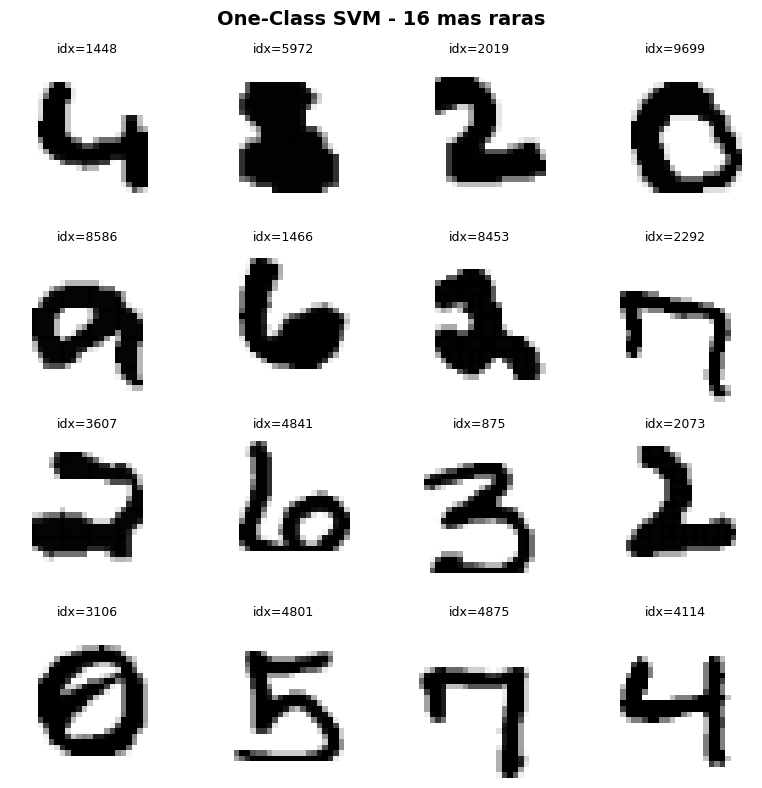

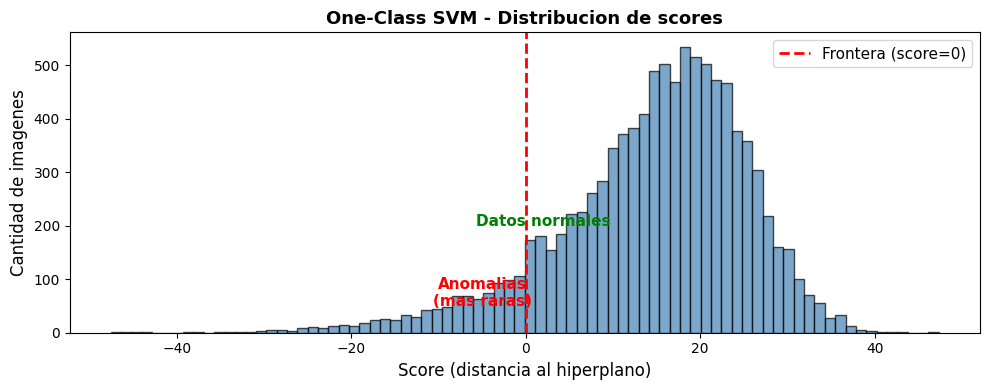

In [ ]:

# =============================================================================
#  METODO 3: SVM DE UNA CLASE (One-Class SVM)
# =============================================================================
#
#  Como funciona (analogia):
#  Imagina una burbuja gigante que intenta envolver a TODOS los datos normales.
#  Los puntos que quedan fuera de la burbuja son anomalias. La "burbuja"
#  es un hiperplano en un espacio de alta dimension.
#
#              .  .  .  .               .  = dato normal (dentro)
#          .  .  .  .  .  .
#         (  .  .  .  .  .  )  <-- hiperplano (frontera)
#          .  .  .  .  .  .
#              .  .  .  .          x  = anomalia (fuera)
#                                x
#
#  decision_function: devuelve la distancia al hiperplano.
#     Positivo  ->  dentro de la burbuja (normal)
#     Negativo  ->  fuera de la burbuja (anomalia)
#     MAS negativo = MAS raro
#
#  Parametros clave:
#  kernel = 'rbf'  ->  Funcion de base radial; permite fronteras no lineales.
#  nu = 0.1        ->  Cota superior del % de errores permitidos (~10%).
#
#  NOTA: OneClassSVM es mas lento que los otros metodos en datasets grandes.
#        Esto es normal, ten paciencia con los 10,000 datos.
#
# =============================================================================

print("\n" + "="*70)
print("  METODO 3: ONE-CLASS SVM (kernel=rbf, nu=0.1)")
print("="*70)
print("  (Este metodo tarda mas, espera un momento...)")

svm = OneClassSVM(kernel='rbf', nu=0.1)
svm.fit(X)

# decision_function: distancia con signo al hiperplano separador
# Valores negativos = anomalia;  mas negativo = mas raro
scores_svm = svm.decision_function(X)

# --- Punto 1: Las 16 imagenes MAS raras (menores scores) ---
# argsort ordena de menor a mayor; los primeros son los mas negativos (mas raros)
indices_top16_svm = np.argsort(scores_svm)[:16]

print(f"\n  Top 16 imagenes mas raras (indices): {indices_top16_svm}")
print(f"  Sus scores (distancia al hiperplano):")
for i, idx in enumerate(indices_top16_svm):
    print(f"    #{i+1:2d}  idx={idx:5d}  score={scores_svm[idx]:.4f}  (digito real: {y[idx]})")

# --- Punto 2: Visualizar las 16 mas raras ---
mostrar_16_anomalias(X, indices_top16_svm, "One-Class SVM - 16 mas raras")

# Grafica extra: distribucion de los scores para entender la decision
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores_svm, bins=80, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Frontera (score=0)')
ax.set_xlabel('Score (distancia al hiperplano)', fontsize=12)
ax.set_ylabel('Cantidad de imagenes', fontsize=12)
ax.set_title('One-Class SVM - Distribucion de scores', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.annotate('Anomalias\n(mas raras)', xy=(-5, 50), fontsize=11, color='red',
            fontweight='bold', ha='center')
ax.annotate('Datos normales', xy=(2, 200), fontsize=11, color='green',
            fontweight='bold', ha='center')
plt.tight_layout()
plt.savefig("fig_svm_distribucion_scores.png", dpi=150, bbox_inches='tight')
plt.show()




  METODO 4: ISOLATION FOREST (contamination=0.05, random_state=42)

  Top 16 imagenes mas raras (indices): [5972 9687 8493 3106 9699 3607 4909 8586 4820 9717 3698 9440 5469 9142
  121 4773]
  Sus scores (puntuacion de anomalia):
    # 1  idx= 5972  score=-0.0794  (digito real: 8)
    # 2  idx= 9687  score=-0.0789  (digito real: 0)
    # 3  idx= 8493  score=-0.0754  (digito real: 2)
    # 4  idx= 3106  score=-0.0743  (digito real: 0)
    # 5  idx= 9699  score=-0.0713  (digito real: 0)
    # 6  idx= 3607  score=-0.0647  (digito real: 2)
    # 7  idx= 4909  score=-0.0607  (digito real: 8)
    # 8  idx= 8586  score=-0.0597  (digito real: 9)
    # 9  idx= 4820  score=-0.0594  (digito real: 5)
    #10  idx= 9717  score=-0.0591  (digito real: 0)
    #11  idx= 3698  score=-0.0577  (digito real: 0)
    #12  idx= 9440  score=-0.0577  (digito real: 0)
    #13  idx= 5469  score=-0.0567  (digito real: 0)
    #14  idx= 9142  score=-0.0567  (digito real: 0)
    #15  idx=  121  score=-0.0551  (digito

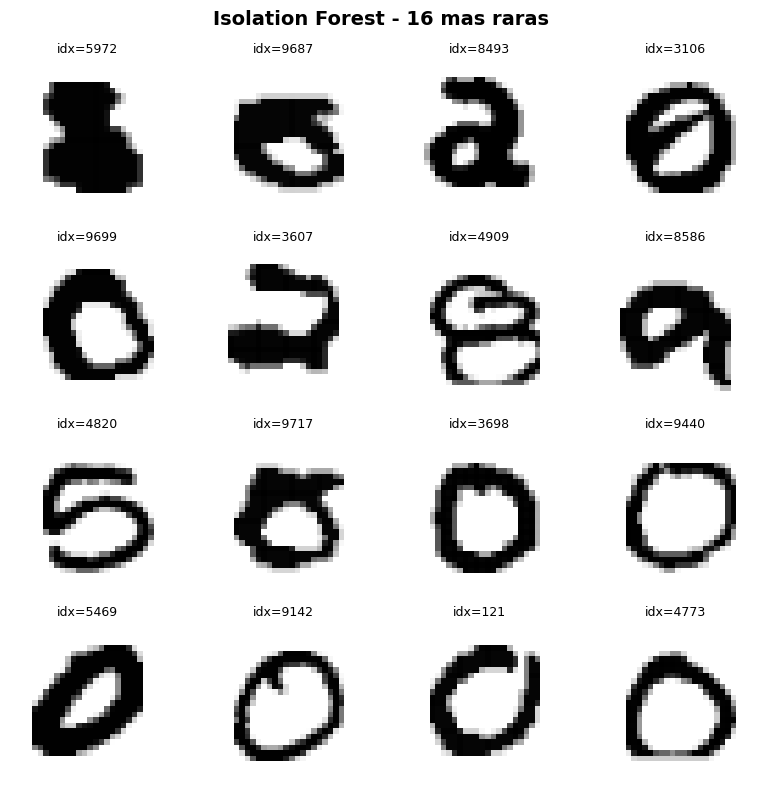

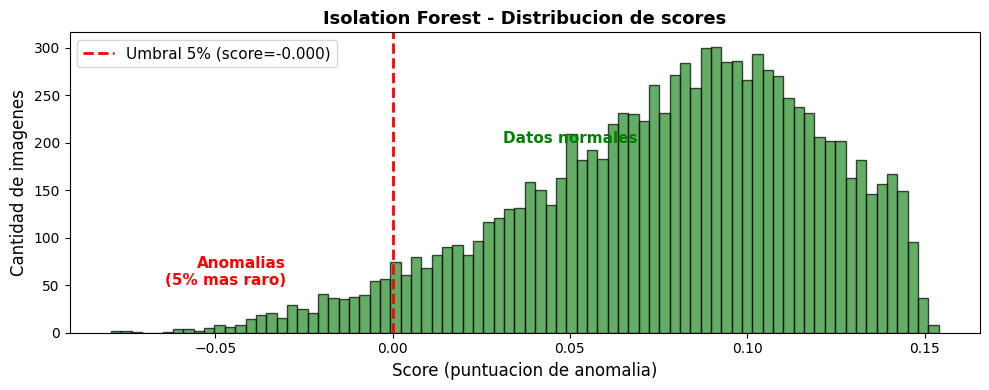

In [ ]:

# =============================================================================
#  METODO 4: ISOLATION FOREST (Bosque de Aislamiento)
# =============================================================================
#
#  Como funciona (analogia):
#  Imagina que quieres separar a UNA persona de un grupo usando cortes
#  aleatorios en un mapa. Si la persona esta en medio del grupo, necesitas
#  MUCHOS cortes para aislarla. Pero si esta sola en una esquina, con
#  MUY POCOS cortes ya queda separada.
#
#     Muchos cortes para aislar (normal):    Pocos cortes para aislar (anomalia):
#
#       |         |                            |
#     --+--*--*---+--                          |    *    (1 solo corte
#       | *[x]* * |  <-- necesito              |         basta para
#       |  * * *  |      5+ cortes             |         aislarlo)
#     --+--*--*---+--
#       |         |
#
#  Los arboles miden cuantas particiones se necesitan. Promediando sobre
#  muchos arboles aleatorios, los puntos con MENOS particiones son anomalias.
#
#  decision_function: similar a SVM, valores mas negativos = mas raro.
#
#  Parametros clave:
#  contamination = 0.05  ->  Estimamos que ~5% de los datos son anomalias.
#  random_state = 42     ->  Semilla para reproducibilidad.
#
# =============================================================================

print("\n" + "="*70)
print("  METODO 4: ISOLATION FOREST (contamination=0.05, random_state=42)")
print("="*70)

iforest = IsolationForest(contamination=0.05, random_state=42)
iforest.fit(X)

# decision_function: puntuacion de anomalia
# Valores mas negativos = mas facil de aislar = mas raro
scores_iforest = iforest.decision_function(X)

# --- Punto 1: Las 16 imagenes MAS raras ---
indices_top16_iforest = np.argsort(scores_iforest)[:16]

print(f"\n  Top 16 imagenes mas raras (indices): {indices_top16_iforest}")
print(f"  Sus scores (puntuacion de anomalia):")
for i, idx in enumerate(indices_top16_iforest):
    print(f"    #{i+1:2d}  idx={idx:5d}  score={scores_iforest[idx]:.4f}  (digito real: {y[idx]})")

# --- Punto 2: Visualizar las 16 mas raras ---
mostrar_16_anomalias(X, indices_top16_iforest, "Isolation Forest - 16 mas raras")

# Grafica extra: distribucion de los scores
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores_iforest, bins=80, color='forestgreen', edgecolor='black', alpha=0.7)
umbral = np.percentile(scores_iforest, 5)  # El 5% mas bajo (contamination=0.05)
ax.axvline(x=umbral, color='red', linestyle='--', linewidth=2,
           label=f'Umbral 5% (score={umbral:.3f})')
ax.set_xlabel('Score (puntuacion de anomalia)', fontsize=12)
ax.set_ylabel('Cantidad de imagenes', fontsize=12)
ax.set_title('Isolation Forest - Distribucion de scores', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.annotate('Anomalias\n(5% mas raro)', xy=(umbral - 0.03, 50), fontsize=11,
            color='red', fontweight='bold', ha='right')
ax.annotate('Datos normales', xy=(0.05, 200), fontsize=11, color='green',
            fontweight='bold', ha='center')
plt.tight_layout()
plt.savefig("fig_iforest_distribucion_scores.png", dpi=150, bbox_inches='tight')
plt.show()



In [ ]:

# =============================================================================
#  COMPARACION FINAL: Que metodo encontro que?
# =============================================================================
#
# Cada algoritmo tiene una filosofia diferente para definir "raro".
# No existe UNA respuesta correcta (es aprendizaje no supervisado).
# Lo interesante es ver donde coinciden y donde difieren.

print("\n" + "="*70)
print("  COMPARACION FINAL DE LOS 4 METODOS")
print("="*70)

# Obtener el top 16 de cada metodo como conjuntos para comparar
top16_lof    = set(indices_lof[:16])
top16_dbscan = set(indices_dbscan[:16])
top16_svm    = set(indices_top16_svm)
top16_iforest = set(indices_top16_iforest)

# Imagenes detectadas por al menos 2 metodos
todos_los_indices = top16_lof | top16_dbscan | top16_svm | top16_iforest
coincidencias = []
for idx in todos_los_indices:
    conteo = sum([idx in top16_lof, idx in top16_dbscan,
                  idx in top16_svm, idx in top16_iforest])
    if conteo >= 2:
        coincidencias.append((idx, conteo))

coincidencias.sort(key=lambda x: -x[1])

print("\n  Imagenes detectadas por 2 o mas metodos:")
print(f"  {'Indice':<10} {'Digito':<10} {'Metodos que la detectaron':>25}")
print(f"  {'-'*10} {'-'*10} {'-'*25}")

for idx, n_metodos in coincidencias:
    metodos = []
    if idx in top16_lof:     metodos.append("LOF")
    if idx in top16_dbscan:  metodos.append("DBSCAN")
    if idx in top16_svm:     metodos.append("SVM")
    if idx in top16_iforest: metodos.append("IForest")
    print(f"  {idx:<10} {y[idx]:<10} {', '.join(metodos):>25}")

if not coincidencias:
    print("  (Ninguna imagen fue detectada por 2+ metodos en el top 16)")

# Resumen de totales
print(f"\n  Resumen de anomalias totales detectadas:")
print(f"    LOF:              {np.sum(es_anomalia_lof):>5} anomalias")
print(f"    DBSCAN:           {np.sum(es_anomalia_dbscan):>5} anomalias")
print(f"    One-Class SVM:    {np.sum(scores_svm < 0):>5} anomalias (score < 0)")
print(f"    Isolation Forest: {np.sum(scores_iforest < umbral):>5} anomalias (5% mas bajo)")

print("\n" + "="*70)
print("  FIN DE LA ACTIVIDAD")
print("="*70)
print("""
  Conclusiones clave:
  - No hay UNA definicion universal de anomalia (depende del metodo).
  - LOF y DBSCAN se basan en DENSIDAD de vecinos.
  - One-Class SVM crea una FRONTERA (hiperplano) alrededor de lo normal.
  - Isolation Forest mide que tan FACIL es aislar un punto.
  - Los metodos pueden coincidir o diferir: eso es aprendizaje no supervisado.
""")


  COMPARACION FINAL DE LOS 4 METODOS

  Imagenes detectadas por 2 o mas metodos:
  Indice     Digito     Metodos que la detectaron
  ---------- ---------- -------------------------
  8586       9                       SVM, IForest
  3607       2                       SVM, IForest
  3106       0                       SVM, IForest
  5972       8                       SVM, IForest
  9699       0                       SVM, IForest
  627        8                        LOF, DBSCAN

  Resumen de anomalias totales detectadas:
    LOF:                119 anomalias
    DBSCAN:             332 anomalias
    One-Class SVM:     1002 anomalias (score < 0)
    Isolation Forest:   500 anomalias (5% mas bajo)

  FIN DE LA ACTIVIDAD

  Conclusiones clave:
  - No hay UNA definicion universal de anomalia (depende del metodo).
  - LOF y DBSCAN se basan en DENSIDAD de vecinos.
  - One-Class SVM crea una FRONTERA (hiperplano) alrededor de lo normal.
  - Isolation Forest mide que tan FACIL es aislar un punt